# Model Algoritma Unsupervised Learning dan Contohnya
Berikut adalah beberapa algoritma Unsupervised Learning yang paling sering digunakan beserta contoh penerapannya di dunia nyata:

## 1. K-Means Clustering: Pengelompokan Tingkat Keparahan Penyakit
Dalam skenario ini, kita memiliki data pasien berdasarkan dua indikator: Tekanan Darah dan Kadar Gula Darah. Kita ingin K-Means mengelompokkan pasien ke dalam 3 kelompok (misal: Risiko Rendah, Risiko Sedang, Risiko Tinggi) secara otomatis.

In [4]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# 1. Simulasi Data Pasien (Tekanan Darah, Gula Darah)
np.random.seed(42)
data_pasien = np.random.randint(low=[90, 70], high=[180, 250], size=(20, 2))
df_kmeans = pd.DataFrame(data_pasien, columns=['Tekanan_Darah', 'Gula_Darah'])

# 2. Inisialisasi K-Means dengan 3 Cluster
kmeans = KMeans(n_clusters=3, random_state=42)
df_kmeans['Cluster_Risiko'] = kmeans.fit_predict(data_pasien)

print("--- Hasil K-Means Clustering Pasien ---")
print(df_kmeans.head())

--- Hasil K-Means Clustering Pasien ---
   Tekanan_Darah  Gula_Darah  Cluster_Risiko
0            141         162               1
1            104         176               0
2            161          90               1
3            172         144               1
4            164         157               1


## 2. Hierarchical Clustering: Struktur Hubungan Gejala Pasien
simulasikan data 6 pasien dengan 5 jenis gejala: Demam, Batuk, Sesak Napas, Hilang Penciuman (Anosmia), dan Nyeri Otot.

Data Gejala Pasien:
   Demam  Batuk  Sesak_Napas  Anosmia  Nyeri_Otot
0      1      1            1        0           0
1      1      1            0        0           1
2      1      0            0        1           1
3      0      0            0        1           1
4      0      1            1        0           0
5      1      1            1        0           0

Data Gejala Transposed:
             0  1  2  3  4  5
Demam        1  1  1  0  0  1
Batuk        1  1  0  0  1  1
Sesak_Napas  1  0  0  0  1  1
Anosmia      0  0  1  1  0  0
Nyeri_Otot   0  1  1  1  0  0


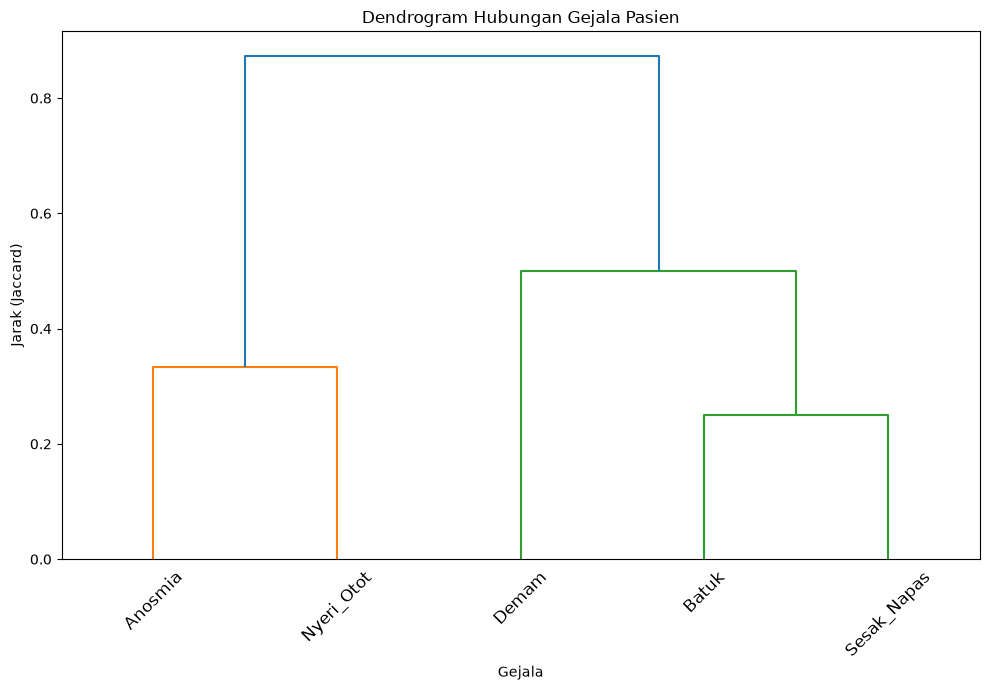


Hasil Pengelompokkan Gejala:
        Gejala  Kluster
3      Anosmia        0
4   Nyeri_Otot        0
1        Batuk        1
0        Demam        1
2  Sesak_Napas        1


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# Simulasi data biner gejala (1 = Ada, 0 = Tidak Ada)
# Baris = Pasien, Kolom = Gejala
data_gejala = {
    'Demam':     [1, 1, 1, 0, 0, 1],
    'Batuk':     [1, 1, 0, 0, 1, 1],
    'Sesak_Napas':[1, 0, 0, 0, 1, 1],
    'Anosmia':   [0, 0, 1, 1, 0, 0],
    'Nyeri_Otot':[0, 1, 1, 1, 0, 0]
}

df = pd.DataFrame(data_gejala)
print("Data Gejala Pasien:")
print(df)

# melihat struktur hubungan antar gejala (bukan mengelompokkan pasien), kita harus melakukan transpose pada data
df_transposed = df.T
print("\nData Gejala Transposed:")
print(df_transposed)

# Menggunakan 'jaccard' sebagai metrik jarak karena datanya biner
# Metode 'average' atau 'complete' cocok untuk melihat struktur hubungan
linked = linkage(df_transposed, method='average', metric='jaccard')

# Visualisasi Struktur Hubungan Gejala dengan Dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, labels=df_transposed.index, orientation='top', leaf_rotation=45)
plt.title('Dendrogram Hubungan Gejala Pasien')
plt.xlabel('Gejala')
plt.ylabel('Jarak (Jaccard)')
plt.tight_layout()
plt.show()

# Menentukan jumlah kluster berdasarkan observasi dendrogram (misal: 2 kluster)
# Menggunakan fcluster dari scipy.cluster.hierarchy untuk konsistensi
kluster_gejala = fcluster(linked, t=2, criterion='maxclust') - 1  # -1 untuk mulai dari 0

# Menampilkan hasil pengelompokkan
hasil = pd.DataFrame({'Gejala': df_transposed.index, 'Kluster': kluster_gejala})
print("\nHasil Pengelompokkan Gejala:")
print(hasil.sort_values(by='Kluster'))

### Analisis Hasil Kluster
Kluster 0 (Kelompok Respirasi / Saluran Pernapasan):
Anggota: Demam, Batuk, Sesak Napas.
Arti Klinis: Ini adalah manifestasi klasik dari infeksi saluran napas akut (seperti pneumonia atau bronkitis). Jika seorang pasien masuk ke rumah sakit dengan salah satu gejala ini, ada kemungkinan besar dua gejala lainnya juga akan menyusul atau sudah dirasakan.

Kluster 1 (Kelompok Sistemik / Neurologis):
Anggota: Anosmia (hilang penciuman) dan Nyeri Otot.
Arti Klinis: Kelompok ini menarik karena tidak langsung berhubungan dengan saluran napas, melainkan respons sistemik tubuh dan gangguan saraf (seperti gejala khas pada fase awal COVID-19).

## 3. Apriori Algorithm: Pola Komoriditas Gejala (Asosiasi)
Dalam dunia medis, gejala atau penyakit sering kali muncul bersamaan (komorbiditas). Kita ingin mencari tahu: "Jika pasien mengalami gejala A dan B, seberapa besar kemungkinan mereka juga mengalami gejala C?"

In [12]:
from sklearn.cluster import AgglomerativeClustering
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings("ignore")  # Untuk mengabaikan peringatan yang tidak penting
# =====================================================================
# BAGIAN 2: ALGORITMA APRIORI (ATURAN ASOSIASI / KOMORBIDITAS)
# =====================================================================

# Cari kombinasi gejala yang sering muncul (minimal muncul di 30% pasien)
frequent_itemsets = apriori(df, min_support=0.3, use_colnames=True)

# Buat aturan asosiasi (minimal keyakinan/confidence 70%)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Rapikan output asosiasi
hasil_asosiasi = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
hasil_asosiasi = hasil_asosiasi.sort_values(by='lift', ascending=False)

print("\n--- HASIL ATURAN ASOSIASI (APRIORI) ---")
# Konversi frozenset ke list biasa agar lebih enak dibaca
hasil_asosiasi['antecedents'] = hasil_asosiasi['antecedents'].apply(lambda x: list(x))
hasil_asosiasi['consequents'] = hasil_asosiasi['consequents'].apply(lambda x: list(x))
print(hasil_asosiasi.to_string(index=False))


--- HASIL ATURAN ASOSIASI (APRIORI) ---
         antecedents   consequents  support  confidence  lift
           [Anosmia]  [Nyeri_Otot] 0.333333        1.00 2.000
       [Sesak_Napas]       [Batuk] 0.500000        1.00 1.500
             [Batuk] [Sesak_Napas] 0.500000        0.75 1.500
[Sesak_Napas, Demam]       [Batuk] 0.333333        1.00 1.500
             [Batuk]       [Demam] 0.500000        0.75 1.125
             [Demam]       [Batuk] 0.500000        0.75 1.125


1. Pola Kluster Neurologis/Sistemik (Asosiasi Paling Kuat)
> Aturan: [Anosmia] -> [Nyeri_Otot]
Support: 0.333 (33.3%) | Confidence: 1.00 (100%) | Lift: 2.000
Arti Klinis: Sebanyak 33,3% dari total seluruh pasien di datamu memiliki kedua gejala ini sekaligus.

> Nilai Krusial: Perhatikan nilai Confidence (1.00) dan Lift (2.000). Nilai Confidence 1.00 artinya 100% pasien yang mengalami Anosmia pasti juga mengalami Nyeri Otot. Nilai Lift sebesar 2.000 adalah yang tertinggi di data ini, membuktikan bahwa kedua gejala ini punya keterikatan biologis yang sangat kuat (bukan kebetulan). Ini memvalidasi kenapa keduanya masuk ke Kluster 1 di analisis sebelumnya.

2. Pola Kluster Respirasi (Saluran Pernapasan)
Di kelompok ini, kita melihat hubungan timbal balik yang kuat antara Sesak Napas, Batuk, dan Demam (Sesuai dengan Kluster 0).

> A. Hubungan Sesak Napas & Batuk
Aturan 1: [Sesak_Napas] -> [Batuk] (Confidence: 1.00 | Lift: 1.500)
Aturan 2: [Batuk] -> [Sesak_Napas] (Confidence: 0.75 | Lift: 1.500)
Arti Klinis: Hubungan ini searah namun kuat. 100% pasien yang sesak napas pasti batuk (Confidence 1.00). Sebaliknya, dari semua pasien yang batuk, "hanya" 75% yang berlanjut menjadi sesak napas (Confidence 0.75).
Insight Medis: Batuk adalah gejala awal yang lebih umum, sementara Sesak Napas adalah indikator keparahan yang muncul kemudian.

> B. Kombinasi Gejala Kompleks
Aturan: [Sesak_Napas, Demam] -> [Batuk]
Support: 0.333 (33.3%) | Confidence: 1.00 (100%) | Lift: 1.500
Arti Klinis: Jika seorang pasien datang ke faskes dengan kondisi sudah Sesak Napas SEKALIGUS Demam, maka 100% dipastikan mereka juga menderita Batuk. Kombinasi tiga gejala ini mencakup 33,3% dari seluruh populasi pasienmu.

> C. Hubungan Batuk & Demam
Aturan 1: [Batuk] -> [Demam] (Confidence: 0.75 | Lift: 1.125)
Aturan 2: [Demam] -> [Batuk] (Confidence: 0.75 | Lift: 1.125)
Arti Klinis: Pasien batuk memiliki peluang 75% untuk demam, dan pasien demam memiliki peluang 75% untuk batuk. Nilai Lift mereka 1.125 (di atas 1, artinya saling terkait, tapi ikatannya tidak sekuat hubungan Anosmia-Nyeri Otot atau Sesak-Batuk).

## 4. PCA (Principal Component Analysis):
Penerapan  PCA pada data biner gejala pasien yang kamu miliki untuk melihat bagaimana 5 gejala tersebut bisa diringkas menjadi 2 komponen utama (PC1 dan PC2).

--- KOORDINAT GEJALA DALAM RUANG PCA ---
                  PC1       PC2
Demam        0.479226  1.706397
Batuk        2.188017  0.264665
Sesak_Napas  2.128891 -1.363324
Anosmia     -2.427630 -1.117864
Nyeri_Otot  -2.368504  0.510125


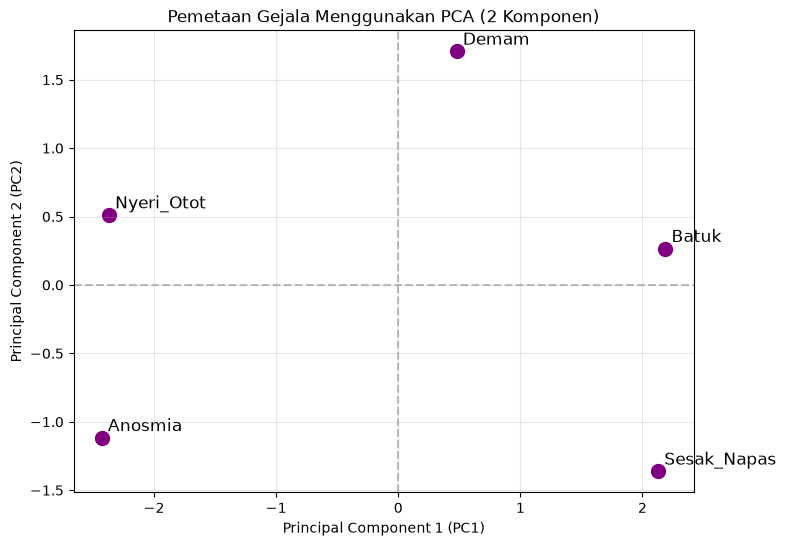


Total varians yang dijelaskan oleh PC1 & PC2: 91.34%


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Kita lakukan PCA pada GEJALA (transpose data agar kolom menjadi baris)
# Menstandarkan data sebelum PCA sangat direkomendasikan
df_gejala = df.T
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_gejala)

# 2. Inisialisasi PCA untuk mereduksi menjadi 2 Komponen (PC1 dan PC2)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)

# Membuat DataFrame hasil PCA
df_pca = pd.DataFrame(
    data = pca_features, 
    columns = ['PC1', 'PC2'],
    index = df_gejala.index
)

print("--- KOORDINAT GEJALA DALAM RUANG PCA ---")
print(df_pca)

# 3. Visualisasi Scatter Plot PCA Gejala
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], color='purple', s=100)

# Memberi label nama gejala pada grafik
for gejala in df_pca.index:
    plt.annotate(gejala, (df_pca.loc[gejala, 'PC1']+0.05, df_pca.loc[gejala, 'PC2']+0.05), fontsize=12)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Pemetaan Gejala Menggunakan PCA (2 Komponen)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, alpha=0.3)
plt.show()

# Menampilkan rasio varians yang berhasil dijelaskan
print(f"\nTotal varians yang dijelaskan oleh PC1 & PC2: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

Cara Membaca Output Gambar PCA
Ketika grafik scatter plot di atas muncul, perhatikan posisi titik-titiknya:

Sisi Kanan vs Sisi Kiri: Kamu akan melihat kelompok Demam, Batuk, dan Sesak_Napas berada di satu kutub sumbu PC1, sedangkan Anosmia dan Nyeri_Otot berada di kutub sebaliknya.

Informasi Kumulatif: Nilai explained_variance_ratio_ akan memberi tahu seberapa banyak informasi dari 5 gejala asli yang berhasil diringkas oleh 2 PC saja (biasanya di atas 70-80%).

### Kesimpulan Trilogi Analisis Data Medis Kamu:
Hierarchical Clustering: Memberitahu kamu siapa berteman dengan siapa (membentuk 2 kelompok sindrom).

Apriori: Memberitahu kamu aturan logikanya (jika ada gejala X, 100% pasti muncul gejala Y).

PCA: Menyederhanakan dan memvisualisasikan posisi kedekatan koordinat gejala/pasien tersebut dalam peta 2 dimensi yang mudah dipahami oleh manajemen medis.

## Pengujian K-Mean Data Pasien Diabetes (misal: Glukosa, Tekanan Darah, IMT(Indeks Massa Tubuh), Insulin)

In [8]:
import joblib
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")


# Define the filename of the saved model
model_filename = 'kmeans_diabetes_risk_model.joblib'

# 1. Load the K-Means model
loaded_kmeans_model = joblib.load(model_filename)
print(f"Model K-Means berhasil dimuat dari: {model_filename}\n")

# 2. Siapkan Data Pasien Baru (Simulasi)
# Pastikan fitur-fitur ini sesuai dengan yang digunakan saat melatih model

np.random.seed(10)
data_diabetes = {
    'Glukosa': np.random.randint(70, 200, 5), # Kadar glukosa puasa
    'Tekanan_Darah': np.random.randint(60, 120, 5), # Tekanan darah
    'IMT': np.random.uniform(18.0, 40.0, 5), # Indeks Massa Tubuh
    'Insulin': np.random.randint(15, 300, 5), # Kadar insulin
    'Usia': np.random.randint(20, 75, 5) # Usia pasien
}
new_patient_data = pd.DataFrame(data_diabetes)

print("Data Pasien Baru yang akan diprediksi:")
display(new_patient_data)

# 3. Gunakan model yang dimuat untuk memprediksi kluster untuk data pasien baru
predicted_new_clusters = loaded_kmeans_model.predict(new_patient_data)

# 4. Tampilkan Prediksi Kluster
print("\nPrediksi Kluster untuk Pasien Baru:")
for i, cluster in enumerate(predicted_new_clusters):
    print(f"Pasien Baru {i+1} diprediksi masuk Kluster ID: {cluster}")
# Create a mapping from Cluster_Risiko ID to a descriptive label

risk_mapping = {
    0: 'Risiko Rendah',
    1: 'Risiko Sedang',
    2: 'Risiko Tinggi'
}

# Opsional: Petakan Kluster ID ke Label Risiko yang bermakna
# Pastikan 'risk_mapping' dari langkah sebelumnya masih tersedia di lingkungan kernel
if 'risk_mapping' in globals():
    predicted_new_risk_labels = [risk_mapping[cluster_id] for cluster_id in predicted_new_clusters]
    print("\nPrediksi Label Risiko untuk Pasien Baru:")
    for i, label in enumerate(predicted_new_risk_labels):
        print(f"Pasien Baru {i+1} diprediksi memiliki: {label}")
else:
    print("\nVariabel 'risk_mapping' tidak tersedia untuk menerjemahkan kluster ke label risiko.")

Model K-Means berhasil dimuat dari: kmeans_diabetes_risk_model.joblib

Data Pasien Baru yang akan diprediksi:


,Glukosa,Tekanan_Darah,IMT,Insulin,Usia
0,79,119,18.553778,31,53
1,195,88,33.602576,254,28
2,85,85,23.842455,69,56
3,134,89,23.799263,137,34
4,183,108,21.308313,77,69



Prediksi Kluster untuk Pasien Baru:
Pasien Baru 1 diprediksi masuk Kluster ID: 0
Pasien Baru 2 diprediksi masuk Kluster ID: 2
Pasien Baru 3 diprediksi masuk Kluster ID: 0
Pasien Baru 4 diprediksi masuk Kluster ID: 1
Pasien Baru 5 diprediksi masuk Kluster ID: 0

Prediksi Label Risiko untuk Pasien Baru:
Pasien Baru 1 diprediksi memiliki: Risiko Rendah
Pasien Baru 2 diprediksi memiliki: Risiko Tinggi
Pasien Baru 3 diprediksi memiliki: Risiko Rendah
Pasien Baru 4 diprediksi memiliki: Risiko Sedang
Pasien Baru 5 diprediksi memiliki: Risiko Rendah
